In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import os

In [2]:
# --- Configuration ---
DATA_PATH = '~/gcs-buckets/National_Income_per_capita_till_2023/'
FILE_PATH = os.path.join(DATA_PATH, 'national_income_per_capita_2023.csv')
FORECAST_HORIZON = 6 # years
TARGET_COLUMN = 'Income_Per_Capita' # Adjust if your column name is different
DATE_COLUMN = 'Year' # Adjust if your column name is different (e.g., 'Date')

In [3]:
# --- 1. Load Data ---
df = pd.read_csv(FILE_PATH)
columns = ["country"] + [str(1970 + i) for i in range(52)]
df = df[columns]
df.head()

,country,1970,1971,1972,1973,1974,1975,1976,1977,1978,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
0,Aruba,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,21395.334635,21530.677930,22415.993250,23278.822727,23167.712306,23716.237874,24187.066461,26027.017124,20584.791260,24724.866572
1,Africa Eastern and Southern,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1326.057821,1310.155272,1326.712853,1222.007579,1154.554761,1298.116409,1241.674597,1212.689013,1098.092611,1214.873282
2,Afghanistan,147.709169,150.772963,128.296489,135.151413,163.370030,173.577068,183.125316,207.427050,227.638311,...,605.752004,597.356158,575.916815,548.968454,484.890590,497.406029,466.570602,468.403506,475.718084,340.523244
3,Africa Western and Central,195.831756,138.579990,162.296828,193.783381,241.071581,290.188233,348.361406,346.829622,379.711153,...,1451.219388,1642.527119,1797.193227,1553.654158,1366.270211,1286.956899,1382.675005,1412.167673,1374.444860,1393.442318
4,Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2865.333338,3185.333640,3486.753100,2371.995619,1206.043537,1500.335741,1506.725371,1327.803449,1100.217496,1231.925133


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 266 entries, 0 to 265
Data columns (total 53 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   country  266 non-null    object 
 1   1970     73 non-null     float64
 2   1971     107 non-null    float64
 3   1972     107 non-null    float64
 4   1973     109 non-null    float64
 5   1974     109 non-null    float64
 6   1975     109 non-null    float64
 7   1976     112 non-null    float64
 8   1977     112 non-null    float64
 9   1978     112 non-null    float64
 10  1979     111 non-null    float64
 11  1980     153 non-null    float64
 12  1981     158 non-null    float64
 13  1982     158 non-null    float64
 14  1983     158 non-null    float64
 15  1984     160 non-null    float64
 16  1985     163 non-null    float64
 17  1986     166 non-null    float64
 18  1987     167 non-null    float64
 19  1988     168 non-null    float64
 20  1989     173 non-null    float64
 21  1990     178 non

In [5]:
df["num_timesteps"] = 0

for i, row in df.iterrows():
    df.at[i, "num_timesteps"] = row[1:].count()

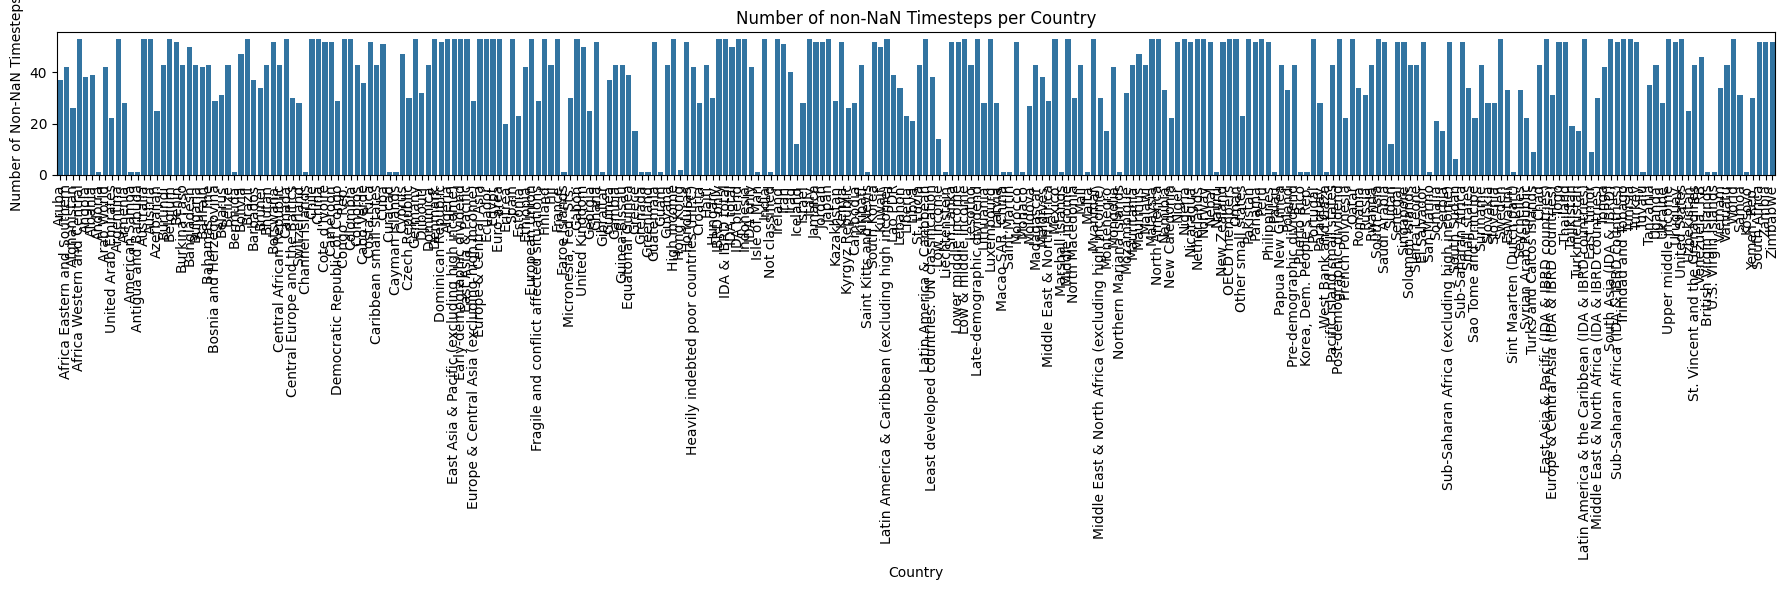

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))
plt.title("Number of non-NaN Timesteps per Country")
sns.barplot(x=df["country"], y=df["num_timesteps"])
# plt.plot(df["num_timesteps"])
plt.xticks(rotation=90)
plt.xlabel("Country")
plt.ylabel("Number of Non-NaN Timesteps")
plt.tight_layout()
plt.show()

In [7]:
country = "United Kingdom"
df1 = df[df["country"] == country].drop(columns=["country","num_timesteps"]).T.reset_index()
df1.rename(columns={df1.columns[0]: DATE_COLUMN, df1.columns[1]: TARGET_COLUMN}, inplace=True)
df1

,Year,Income_Per_Capita
0,1970,2267.450040
1,1971,2534.270487
2,1972,2881.707738
3,1973,3246.470747
4,1974,3456.507280
5,1975,4064.554993
6,1976,3891.152906
7,1977,4308.658951
8,1978,5473.196929
9,1979,6967.861662


In [9]:
# Convert the date column to datetime objects and set as index
# Assuming 'Year' is an integer, convert it to a string for parsing 'YYYY-01-01'
df1[DATE_COLUMN] = pd.to_datetime(df1[DATE_COLUMN].astype(str) + '-01-01')
df1.set_index(DATE_COLUMN, inplace=True)
df1 = df1.sort_index()

# Ensure the frequency is set for time series operations (Year Start)
df1 = df1.asfreq('YS')

print("Data Head:")
print(df1.head())

Data Head:
            Income_Per_Capita
Year                         
1970-01-01        2267.450040
1971-01-01        2534.270487
1972-01-01        2881.707738
1973-01-01        3246.470747
1974-01-01        3456.507280


In [10]:
print("\nData Info:")
df1.info()


Data Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 52 entries, 1970-01-01 to 2021-01-01
Freq: YS-JAN
Data columns (total 1 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Income_Per_Capita  49 non-null     float64
dtypes: float64(1)
memory usage: 832.0 bytes


In [11]:
print("\nData Description:")
print(df1.describe())


Data Description:
       Income_Per_Capita
count          49.000000
mean        20080.320370
std         13042.661217
min          2267.450040
25%          7601.090534
50%         17960.752838
75%         34106.744384
max         42710.970880


In [12]:
# Check for missing values
print("\nMissing values per column:")
print(df1.isnull().sum())
# Handle missing values if any (e.g., df.fillna(method='ffill', inplace=True))
# For annual income, it's less likely to have internal missing values, but good to check.


Missing values per column:
Income_Per_Capita    3
dtype: int64



--- Performing EDA ---


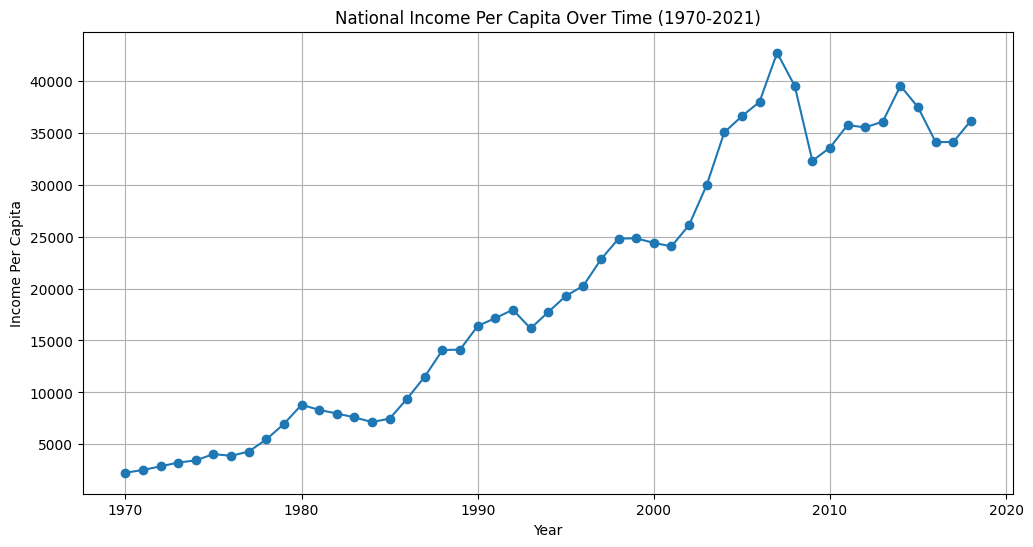

In [15]:
# --- 2. Exploratory Data Analysis (EDA) ---
print("\n--- Performing EDA ---")

# Plot time series
plt.figure(figsize=(12, 6))
plt.plot(df1.index, df1[TARGET_COLUMN], marker='o')
plt.title(f'National Income Per Capita Over Time ({df1.index.min().year}-{df1.index.max().year})')
plt.xlabel('Year')
plt.ylabel('Income Per Capita')
plt.grid(True)
plt.savefig('income_time_series.png') # Save plot to VM
plt.show() # Will only show if you run locally or use a display server

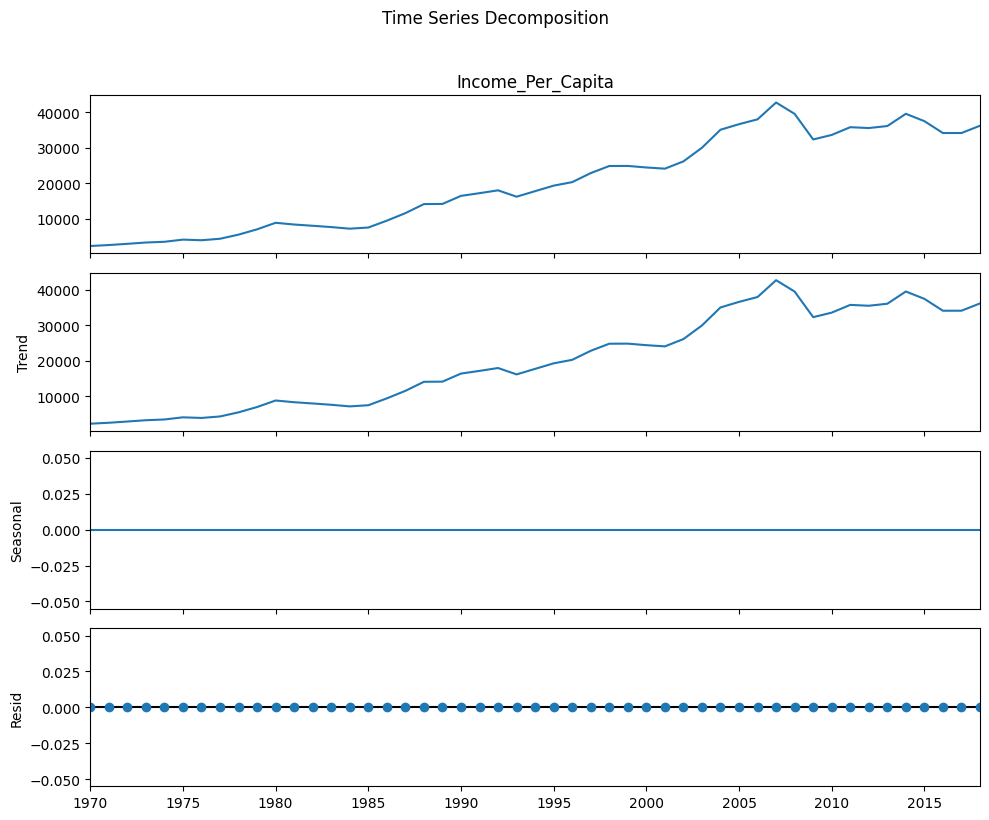

In [18]:
# Time Series Decomposition (Trend, Seasonality, Residuals)
# For annual data, seasonality might not be meaningful or will be represented as a cycle.
# period=1 is often used for annual data to signify no real repeating seasonality within the year.
# However, if there are long term cycles (e.g., business cycles), decompose can show them as trends.
try:
    decomposition = seasonal_decompose(df1[~df1[TARGET_COLUMN].isnull()][TARGET_COLUMN], model='additive', period=1) # period=1 for annual non-seasonal
    fig = decomposition.plot()
    fig.set_size_inches(10, 8)
    plt.suptitle('Time Series Decomposition', y=1.02)
    plt.tight_layout()
    plt.savefig('time_series_decomposition.png')
    plt.show()
except Exception as e:
    print(f"Could not perform decomposition (e.g., not enough data points for period): {e}")

In [20]:
# Stationarity Check (Augmented Dickey-Fuller Test)
print("\n--- ADF Test for Stationarity ---")
result = adfuller(df1[~df1[TARGET_COLUMN].isnull()][TARGET_COLUMN])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] > 0.05:
    print("Series is likely non-stationary. Consider differencing.")
else:
    print("Series is likely stationary.")

# If non-stationary, apply differencing and re-check (e.g., df[TARGET_COLUMN].diff().dropna())
# For auto_arima, it will handle differencing automatically.


--- ADF Test for Stationarity ---
ADF Statistic: -0.5917904328111152
p-value: 0.8728262831679074
Critical Values:
	1%: -3.5925042342183704
	5%: -2.931549768951162
	10%: -2.60406594375338
Series is likely non-stationary. Consider differencing.
